In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

In [2]:
includet("../../../cluster_env/runs/mm_v2_explike/v3.jl")

In [4]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

In [5]:
lindex = 20

20

# Make a lengthscales thr vs PDEs comparison plot

countmap(f["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)


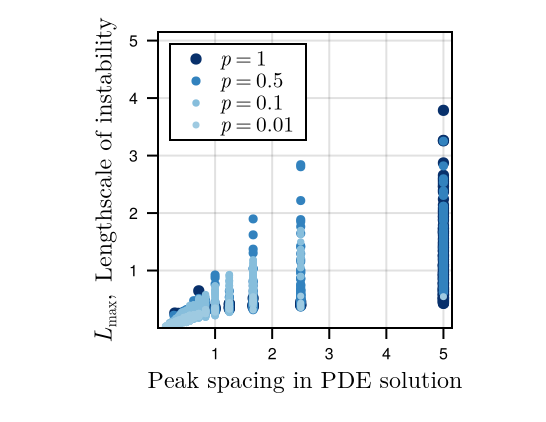

In [242]:
DRs = [1.0, 0.5, 0.1, 0.01]
# DRs = [1.0]

cc = cgrad(ColorSchemes.Blues[4:end])

DRmin, DRmax = extrema(DRs)
DRdelta = DRmax - DRmin

fig = Figure(;
    size=(double_col_width * 0.40, (double_col_width / golden_ratio) * 0.5),
)
ax = Axis(fig[1,1];
    aspect=AxisAspect(1.),
    xlabel=L"\text{Peak spacing in PDE solution}",
    ylabel=L"L_\text{max},\enspace\text{Lengthscale of instability}",
    # xscale=log10,
    # yscale=log10
    # xlabel=L"\text{Space}",
    # ylabel=L"\text{Biomass}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

for DR in DRs
    fname = @sprintf "../../cluster_env/runs/mm_v2_explike/lowDRs/v3_lowDR%.3f.jld2" DR
    f = jldopen(fname);
    @show countmap(f["retcodes"])
    @show countmap(f["ns_retcodes"])
    logKs = f1["logKs"]
    Ks = 10 .^ logKs
    ls = f1["ls"]
    p = f["DR"] / f["DI"]

    (; full_peaks, numpeaks, avg_pkh, avg_pkw, avg_pkp, avg_pksp) = get_peaks(f)

    pp = [(K, l) for K in Ks, l in ls]
    oo = map(pp) do (K, l)
        beta = K * f["c"] / (f["m"] * 1)
        km2 = MinimalModelV2.fr2_km2(beta, l, p, 1.)
        MinimalModelV2.ksquared_to_L(km2)
    end

    ccrat = (DR - DRmin) / DRdelta
    scatter!(ax, avg_pksp[:], oo[:];
        color=get(cc, ccrat),
        # markersize=8,
        markersize=5 + 3 * ccrat,
        label=latexstring(@sprintf "p=%.3g" DR),
    )
end

ax.xticks = 1:5
ax.yticks = 1:5
xlims!(ax, (0, 5.15))
ylims!(ax, (0, 5.15))

axislegend(ax;
    position=:lt,
    labelsize=8fontsize_pt,
    patchsize=(14., 11.),
    rowgap=0.,
    padding=(6., 6., 2., 2.),
)

Makie.save("../../figures/fig3/lengthscomp.pdf", fig)

fig

# Example spatial structure (peaks)

In [6]:
f1 = jldopen("../../../cluster_env/runs/mm_v2_explike/lowDRs/v3_lowDR1.000.jld2");
# f1 = jldopen("../../cluster_env/runs/mm_v2_explike/lowDRs/v3_lowDR0.010.jld2");
@show countmap(f1["retcodes"])
@show countmap(f1["ns_retcodes"]);

countmap(f1["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f1["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)


In [7]:
community_color = colorant"#f1b6daff"
crossfed_resource_color = colorant"#80cdc1ff"
influx_resource_color = colorant"#ffdf79ff";

In [8]:
Ki = 42
li = 30
logK = f1["logKs"][Ki]
l = f1["ls"][li]
@show logK l

dx = f1["L"] / f1["sN"]
@show dx
xs = ((1:f1["sN"]) .- 1) .* dx;

fs = f1["final_states"][Ki, li]
@show sum(@view fs[1,:])

odefs = f1["ns_final_states"][Ki, li]

logK = 1.183838383838384
l = 0.99
dx = 0.001
sum(#= In[8]:12 =# @view(fs[1, :])) = 63155.54230759561


3-element Vector{Float64}:
 13.205815890477952
  1.0749102445285499
  0.9892508975547145

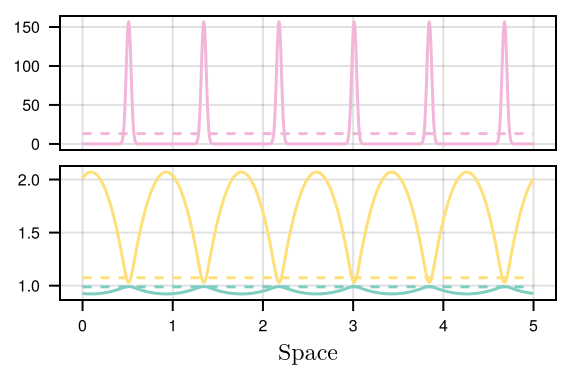

In [26]:
fig = Figure(;
    size=(double_col_width * 0.42, (double_col_width / golden_ratio) * 0.45),
    # size=(double_col_width * 0.35, (double_col_width / golden_ratio) * 0.5 * 0.75),
    figure_padding=(8., 8., 8., 8.),
)
ax1 = Axis(fig[1,1];
    # xscale=log10,
    # yscale=log10
    # title=L"\text{Spatial structure at}\enspace \beta=15, l=0.99, p=1",
    xlabel=L"\text{Space in non-dimensionalized units}",
    # ylabel=L"\text{Biomass}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)
ax2 = Axis(fig[2,1];
    # xscale=log10,
    # yscale=log10
    xlabel=L"\text{Space}",
    # ylabel=papa,
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)
linkxaxes!(ax1, ax2)
hidexdecorations!(ax1; grid=false)
rowgap!(fig.layout, 8.)

lines!(ax1, xs, fs[1,:];
    color=community_color,
)
lines!(ax1, xs, fill(odefs[1], length(xs));
    color=community_color,
    linestyle=:dash,
)

lines!(ax2, xs, fs[2,:];
    color=influx_resource_color,
)
lines!(ax2, xs, fs[3,:];
    color=crossfed_resource_color,
)
lines!(ax2, xs, fill(odefs[2], length(xs));
    color=influx_resource_color,
    linestyle=:dash,
)
lines!(ax2, xs, fill(odefs[3], length(xs));
    color=crossfed_resource_color,
    linestyle=:dash,
)

ax1.xticks = 0:5
ax2.xticks = 0:5

Makie.save("../../../figures/fig3_mm_what/poster_pdes_example.pdf", fig)

fig

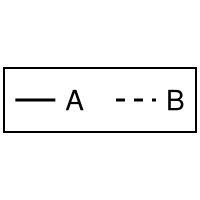

In [340]:
fig = Figure(;
    size=(100, 100),
)

Legend(fig[1,1],
    [
        LineElement(; color=:black),
        LineElement(; color=:black, linestyle=:dash),
    ],
    ["A", "B"];
    orientation=:horizontal
)

fig

# Plotting biomass difference vs K for a couple of ps

In [36]:
lindex = 22

DRs = [1.0, 0.5, 0.1, 0.01]
diffs = []

logKs = nothing
l = nothing

for DR in DRs
    fname = @sprintf "../../../cluster_env/runs/mm_v2_explike/lowDRs/v3_lowDR%.3f.jld2" DR
    f = jldopen(fname);
    @show countmap(f["retcodes"])
    @show countmap(f["ns_retcodes"])
    @show f["ls"][lindex]
    
    if isnothing(logKs)
        logKs = f["logKs"]
        l = f["ls"][lindex]
    end
    
    xx = f["final_states"][:,lindex];
    pdes_biomass = [mean(@view yy[1,:]) for yy in xx];

    xx = f["ns_final_states"][:,lindex];
    odes_biomass = getindex.(xx, 1);
    
    diff = Vector{Float64}(undef, length(odes_biomass))
    for i in 1:length(odes_biomass)
        xode = odes_biomass[i]
        xpde = pdes_biomass[i]
        
        dd = xpde - xode
        if abs(xode) > 1e-9
            diff[i] = dd / xode
        elseif abs(dd) > 1e-9
            @show xode dd
            diff[i] = 100.
        else
            diff[i] = 0.
        end
    end
    diff .*= 100

    # diff = pdes_biomass .- odes_biomass
    # tot = pdes_biomass .+ odes_biomass
    # diff .*= f["L"]
    
    push!(diffs, diff)
    
    close(f)
end

countmap(f["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
(f["ls"])[lindex] = 0.8869422689674907
countmap(f["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
(f["ls"])[lindex] = 0.8869422689674907
countmap(f["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
(f["ls"])[lindex] = 0.8869422689674907
countmap(f["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
(f["ls"])[lindex] = 0.8869422689674907


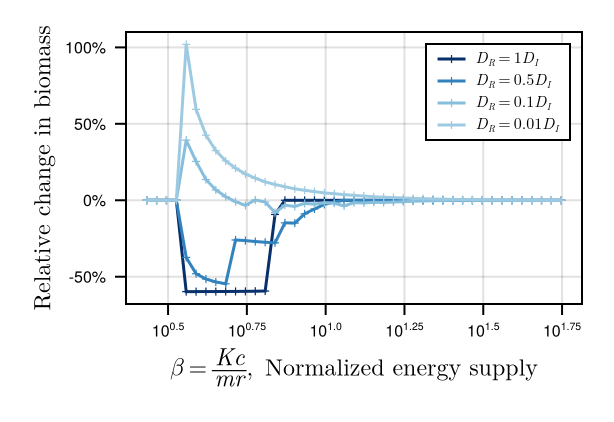

In [47]:
Ks = 10 .^ logKs

# iis = 15:60
iis = 18:60

# cc = cgrad(ColorSchemes.dense[50:end])
cc = cgrad(ColorSchemes.Blues[4:end])

DRmin, DRmax = extrema(DRs)
DRdelta = DRmax - DRmin

fig = Figure(;
    size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.5),
)
ax = Axis(fig[1,1];
    xscale=log10,
    # yscale=log10
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    ylabel=L"\text{Relative change in biomass}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

for i in 1:length(DRs)
    scatterlines!(ax, Ks[iis], diffs[i][iis];
        marker='+',
        label=latexstring(@sprintf "D_R=%.3gD_I" DRs[i]),
        color=get(cc, (DRs[i] - DRmin) / DRdelta)
    )
end

axislegend(ax;
    position=:rt,
    labelsize=6fontsize_pt,
    patchsize=(14., 11.),
    rowgap=0.,
    padding=(6., 6., 2., 2.),
)

oaoa = (0.5:0.25:2.)
ax.xticks = (10. .^ oaoa, [rich("10", superscript(string(e))) for e in oaoa])

ax.yticks = ([-50, 0, 50, 100], ["-50%", "0%", "50%", "100%"])

# Makie.save("../../figures/fig3_mm_what/relbiomasschange.pdf", fig)
Makie.save("../../../figures/fig3_mm_what/poster_biomasschange.pdf", fig)

fig

# Testing

In [5]:
# f1 = jldopen("../../cluster_env/runs/mm_v2_explike/lowDRs/v3_lowDR1.000.jld2");
f1 = jldopen("../../cluster_env/runs/mm_v2_explike/lowDRs/v3_lowDR0.010.jld2");
@show countmap(f1["retcodes"])
@show countmap(f1["ns_retcodes"])
@show f1["ls"][lindex]

countmap(f1["retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
countmap(f1["ns_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 3000)
(f1["ls"])[lindex] = 0.8062884996143342


0.8062884996143342

In [6]:
xx = f1["final_states"][:,lindex];
pdes_biomass = [mean(@view yy[1,:]) for yy in xx];

In [7]:
xx = f1["ns_final_states"][:,lindex];
odes_biomass = getindex.(xx, 1);

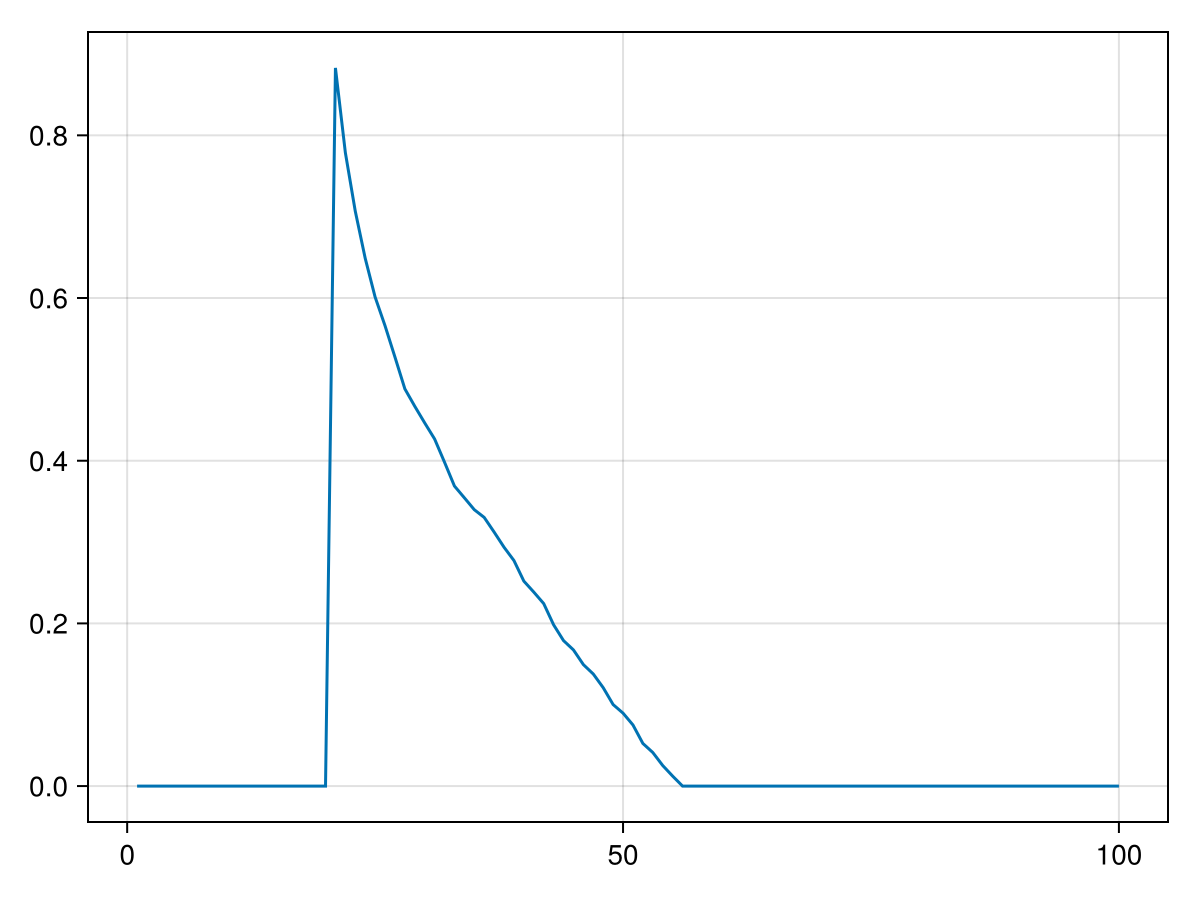

In [8]:
fig = Figure()
ax = Axis(fig[1,1];
    # xscale=log10
    # yscale=log10
)
lines!(ax, pdes_biomass .- odes_biomass)

fig

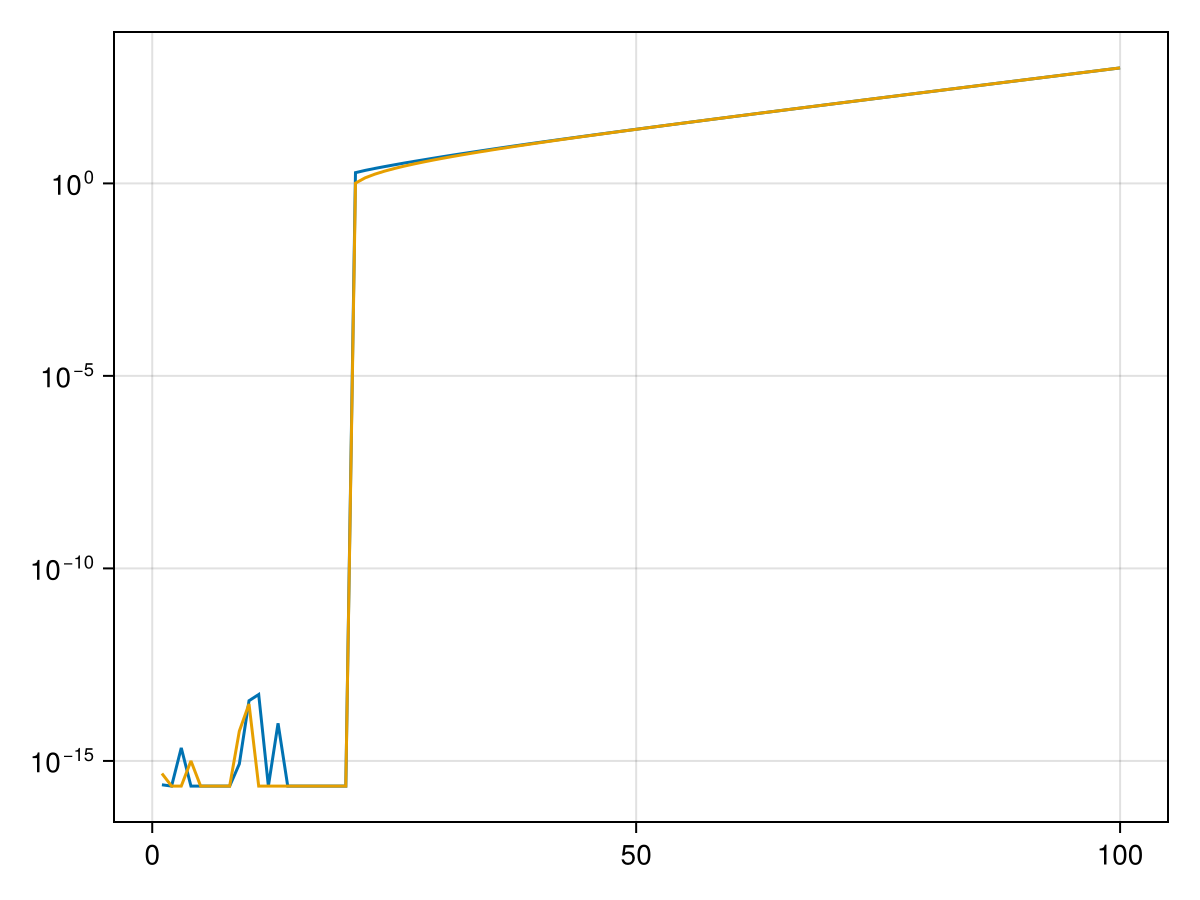

In [9]:
fig = Figure()
ax = Axis(fig[1,1];
    # xscale=log10
    yscale=log10
)
lines!(ax, max.(pdes_biomass, eps()))
lines!(ax, max.(odes_biomass, eps()))

fig